# Heurística Descida em Vizinhança Variável (DVV): Problema da Mochila Para Otimização de Seleção de Coeficientes Wavelet

*Laura Armiliato Sangalli*


---


A seguir, é implementado um algoritmo guloso, uma heurísitca de refinamento de Descida em Vizinhanca Variável e uma meta-heurística *Simulated Annealing* para o problema da mochila aplicado à seleção de coeficientes wavelet. Os coeficientes são tratados como itens, com valor associado à sua energia e peso relacionado à energia total da banda a qual pertencem. A proposta é selecionar automaticamente os coeficientes mais relevantes sob uma restrição de capacidade, de forma que o sinal possa ser reconstruido sob limitações de armazenamento, mas com perdas mínimas de informação.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
import time

## Implementação da Heurística com diferentes sinais de entrada

Obs.: Todos os sinais iniciais são contituídos por um vetor de 1000 amostras. Onde houver

```
np.random.rand(a)
```
significa que um ruído foi simulado.


Os tempos de plot dos gráficos foram desconsiderados.

In [ ]:
# Algoritmo Guloso
# Passo 1: lista as bandas em ordem de magnitude decrescente
# Passo 2: Define um limiar igual a média da magnitude de todos os coeficientes da decomposição Wavelet
# Passo 3: enquanto a mochila tiver espaço livre, vai avançando as bandas
# até que ela seja completa por coeficientes com valor maior que o limiar definido

def algoritmo_guloso(c, capacidade=50):

    # cria estrutura zerada
    selecionados = [np.zeros_like(b) for b in c]

    # junta todos coeficientes para calcular limiar
    todos = np.concatenate(c)
    limiar = np.mean(np.abs(todos))

    acc = 0

    # percorre bandas
    for b_idx, banda in enumerate(c):

        for i, val in enumerate(banda):

            if acc >= capacidade:
                break

            if abs(val) >= limiar:
                selecionados[b_idx][i] = val
                acc += 1

        if acc >= capacidade:
            break

    return selecionados

In [ ]:
def dvv(c, sinal_original, capacidade=50, max_iter=50):

    # solução gulosa
    estrutura = algoritmo_guloso(c, capacidade)

    def contar():
        return sum(np.count_nonzero(b) for b in estrutura)

    def reconstruir():
        return pywt.waverec(estrutura, wavelet)

    def rmse(x, y):
        y = y[:len(x)]
        return np.sqrt(np.mean((x - y)**2))

    melhor_rmse = rmse(sinal_original, reconstruir())

    # busca na banda menor energia primeiro
    energias = [np.linalg.norm(b) for b in estrutura]
    ordem = np.argsort(energias)

    for _ in range(max_iter):

        melhorias = 0

        for b_idx in ordem:

            banda = estrutura[b_idx]
            original = c[b_idx]

            selecionados = np.where(banda != 0)[0]
            nao_sel = np.where(banda == 0)[0]


            for i in selecionados:
                for j in nao_sel:

                    # swap
                    val_i = banda[i]
                    banda[i] = 0
                    banda[j] = original[j]

                    if contar() <= capacidade:

                        novo_rmse = rmse(sinal_original, reconstruir())

                        if novo_rmse < melhor_rmse:
                            melhor_rmse = novo_rmse
                            melhorias += 1
                            break

                    # desfaz se não houver melhoria
                    banda[i] = val_i
                    banda[j] = 0


        if melhorias == 0:
            break

    return estrutura, melhor_rmse

In [ ]:
import copy

def f(s_candidata, target):
  y_s = pywt.waverec(s_candidata, wavelet='db7')
  Y = pywt.waverec(target, wavelet='db7')
  rsme = np.sqrt(np.mean((y_s - Y)**2))
  return rsme

def encontrar_solucao_candidata(S, target, trocas=2):

    candidato = copy.deepcopy(S)

    ativos = []
    inativos = []

    for b in range(len(candidato)):
        for i in range(len(candidato[b])):

            if candidato[b][i] != 0:
                ativos.append((b,i))
            else:
                inativos.append((b,i))

    trocas = min(trocas,
                 len(ativos),
                 len(inativos))

    remover = np.random.choice(len(ativos),
                               trocas,
                               replace=False)

    adicionar = np.random.choice(len(inativos),
                                 trocas,
                                 replace=False)

    # Remove
    for idx in remover:

        b,i = ativos[idx]

        candidato[b][i] = 0

    # Adiciona
    for idx in adicionar:

        b,i = inativos[idx]

        candidato[b][i] = target[b][i]

    return candidato

def simulated_annealing(
        S0,
        target,
        T0=5,
        alpha=0.97,
        Tmin=1e-3,
        iteracoes=500,
        trocas=2):

    import copy

    S = copy.deepcopy(S0)

    custo_atual = f(S,target)

    melhor = copy.deepcopy(S)
    melhor_custo = custo_atual

    historico = [melhor_custo]

    T = T0

    while T > Tmin:

        for _ in range(i):

            candidato = encontrar_solucao_candidata(
                S,
                target,
                trocas
            )

            custo_candidato = f(candidato,target)

            delta = custo_candidato - custo_atual

            if delta < 0:

                S = candidato
                custo_atual = custo_candidato

            else:

                prob = np.exp(-delta/T)

                if np.random.rand() < prob:

                    S = candidato
                    custo_atual = custo_candidato

            if custo_atual < melhor_custo:


                # print(
                #     f"Nova melhor solução | "
                #     f"T={T:.4f} | "
                #     f"RMSE={melhor_custo:.6f}"
                # )

                melhor = copy.deepcopy(S)
                melhor_custo = custo_atual

            historico.append(melhor_custo)

        T *= alpha

        # print(f"T={T:.4f}   Melhor={melhor_custo:.6f}")

    return melhor, melhor_custo, historico

In [ ]:
def exibir(x, y, titulo):
    y = y[:len(x)]
    plt.plot(x, label='Original')
    plt.plot(y, label='Reconstruído')
    plt.title(titulo)
    plt.legend()

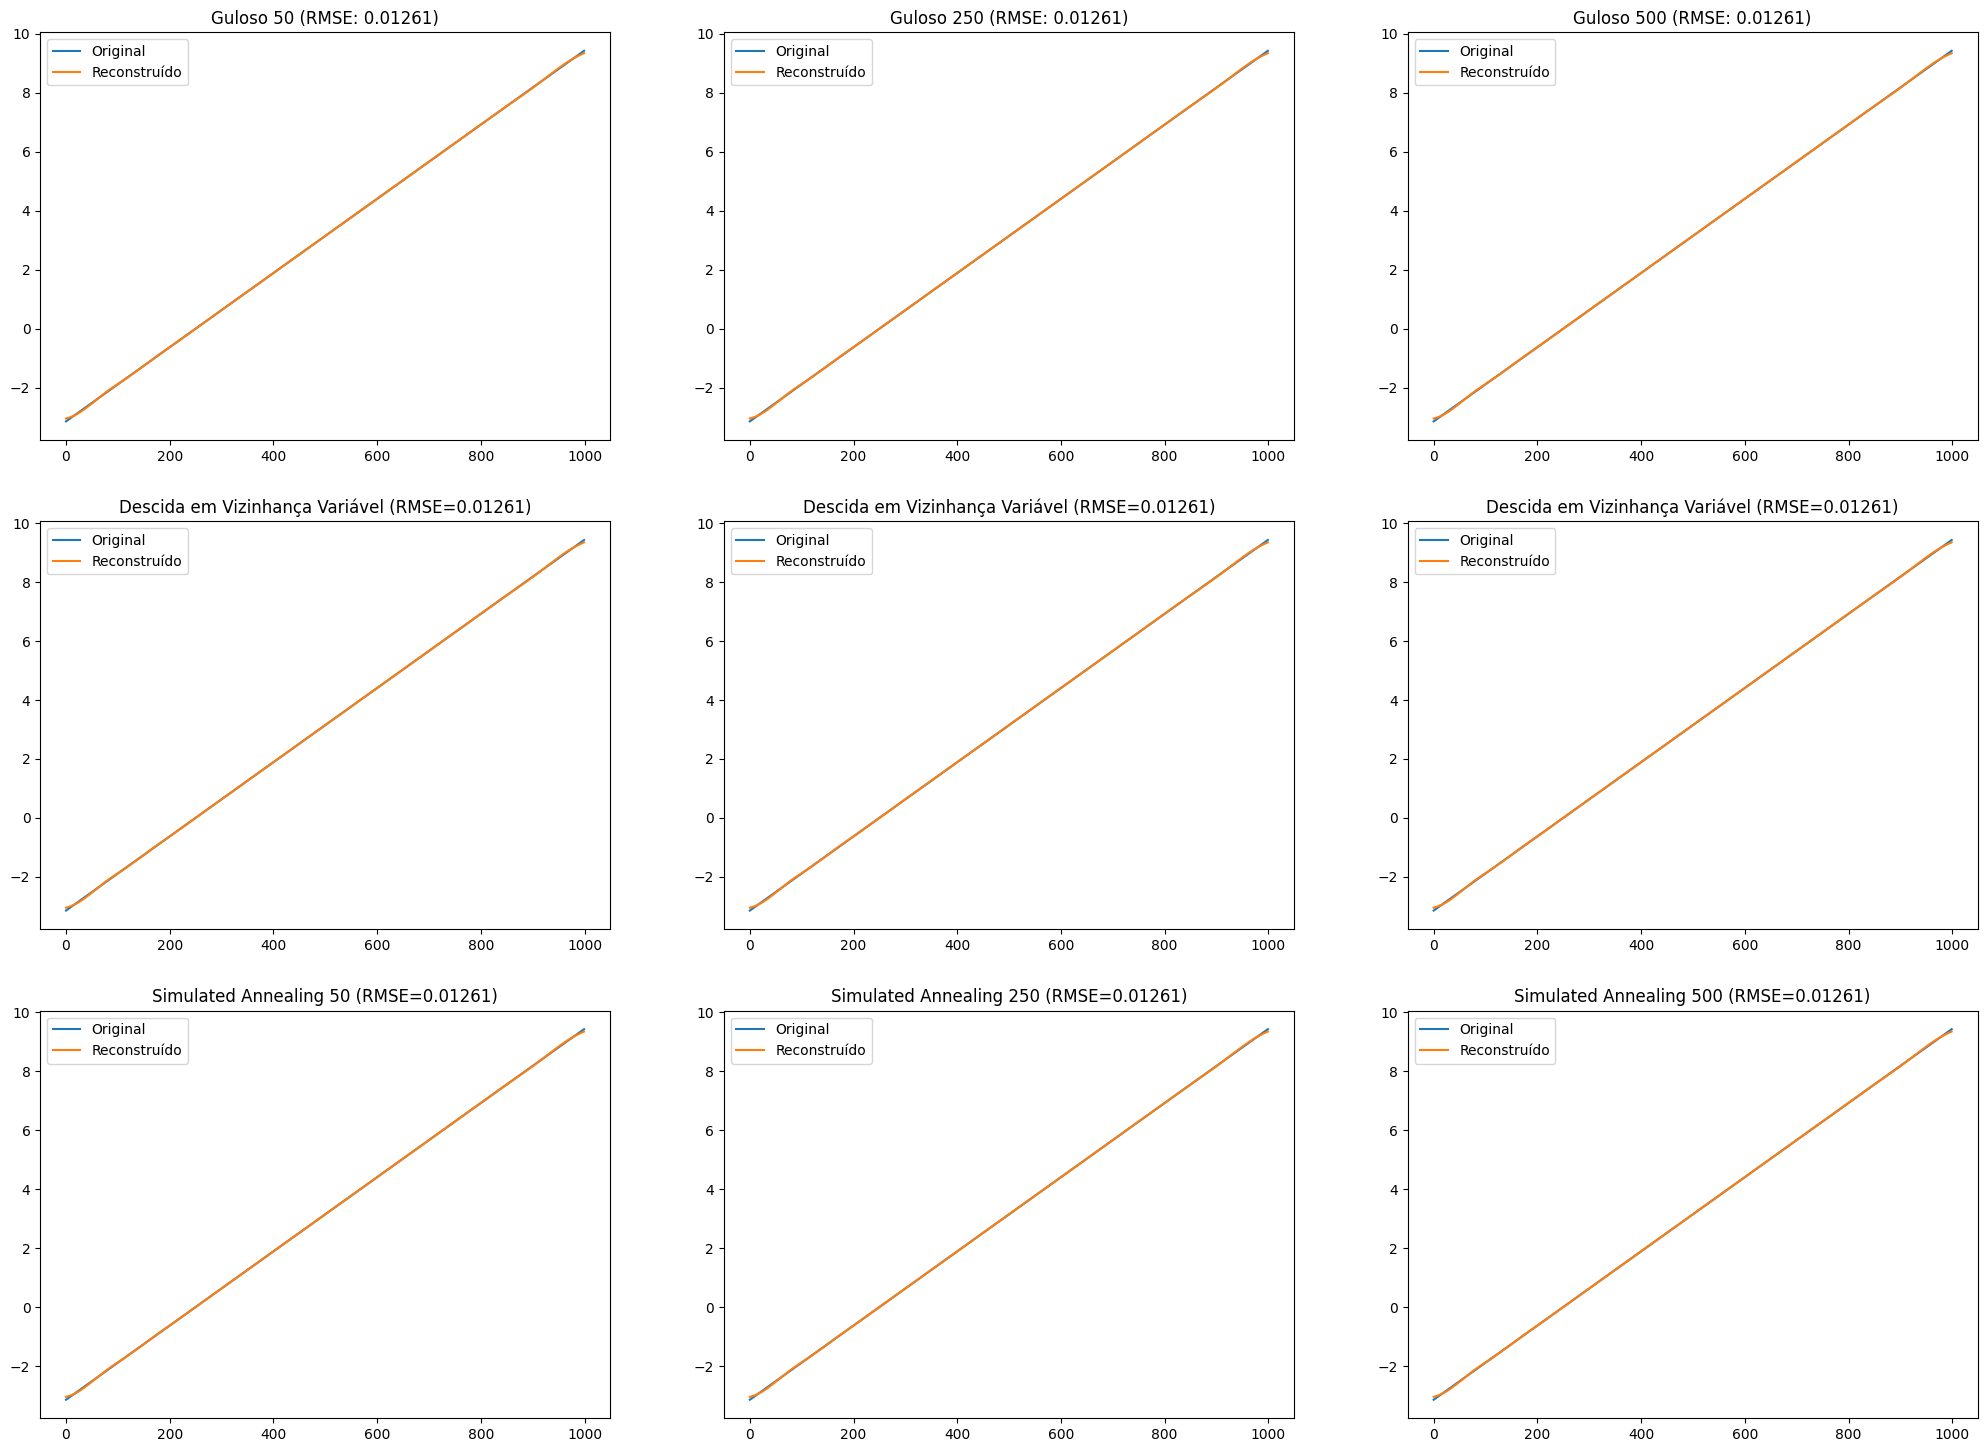


TEMPOS:
metodo guloso 50: 0.0021142959594726562
metodo guloso 250: 0.0021038055419921875
metodo guloso 500: 0.0020856857299804688
DVV50: 0.01304316520690918
DVV250: 0.0029032230377197266
DVV500: 0.0028107166290283203
Simulated Annealing 50: 83.9777090549469
Simulated Annealing 250: 77.86457538604736
Simulated Annealing 500: 70.07872557640076


In [ ]:
a = np.linspace(-np.pi, 3*np.pi, 1000)
x = a

wavelet = 'db7'

start = time.time()
c = pywt.wavedec(x, wavelet)
end = time.time()

base = end - start

# =====================


plt.figure(figsize=(25,18))
plt.axis('off')

# GULOSO 50
plt.subplot(331)
start = time.time()
g50 = algoritmo_guloso(c, 50)
y = pywt.waverec(g50, wavelet)
t50 = base + (time.time() - start)
exibir(x, y, f'Guloso 50 (RMSE: {np.sqrt(np.mean((x - y)**2)):.5f})')

# GULOSO 250
plt.subplot(332)
start = time.time()
g250 = algoritmo_guloso(c, 250)
y = pywt.waverec(g250, wavelet)
t250 = base + (time.time() - start)
exibir(x, y, f'Guloso 250 (RMSE: {np.sqrt(np.mean((x - y)**2)):.5f})')

# GULOSO 500
plt.subplot(333)
start = time.time()
g500 = algoritmo_guloso(c, 500)
y = pywt.waverec(g500, wavelet)
t500 = base + (time.time() - start)
exibir(x, y, f'Guloso 500 (RMSE: {np.sqrt(np.mean((x - y)**2)):.5f})')

# Descida em Vizinhança Variável 50
plt.subplot(334)
start = time.time()
hc, err = dvv(c, x, 50)
y = pywt.waverec(hc, wavelet)
dvv50 = base + (time.time() - start)
exibir(x, y, f'Descida em Vizinhança Variável (RMSE={err:.5f})')

# Descida em Vizinhança Variável 250
plt.subplot(335)
start = time.time()
hc, err = dvv(c, x, 250)
y = pywt.waverec(hc, wavelet)
dvv250 = base + (time.time() - start)
exibir(x, y, f'Descida em Vizinhança Variável (RMSE={err:.5f})')


# Descida em Vizinhança Variável 500
plt.subplot(336)
start = time.time()
hc, err = dvv(c, x, 500)
y = pywt.waverec(hc, wavelet)
dvv500 = base + (time.time() - start)
exibir(x, y, f'Descida em Vizinhança Variável (RMSE={err:.5f})')

# Simulated Annealing 50
plt.subplot(337)
start = time.time()
s_inicial = algoritmo_guloso(c, capacidade=50)
melhor, melhor_custo, _ = simulated_annealing(s_inicial, c)
y = pywt.waverec(melhor, wavelet)
sa50 = base + (time.time() - start)
exibir(x, y, f'Simulated Annealing 50 (RMSE={err:.5f})')

# Simulated Annealing 250
plt.subplot(338)
start = time.time()
s_inicial = algoritmo_guloso(c, capacidade=250)
melhor, melhor_custo, _ = simulated_annealing(s_inicial, c)
y = pywt.waverec(melhor, wavelet)
sa250 = base + (time.time() - start)
exibir(x, y, f'Simulated Annealing 250 (RMSE={err:.5f})')

# Simulated Annealing 500
plt.subplot(339)
start = time.time()
s_inicial = algoritmo_guloso(c, capacidade=500)
melhor, melhor_custo, _ = simulated_annealing(s_inicial, c)
y = pywt.waverec(melhor, wavelet)
sa500 = base + (time.time() - start)
exibir(x, y, f'Simulated Annealing 500 (RMSE={err:.5f})')

plt.show()

print("\nTEMPOS:")
print("metodo guloso 50:", t50)
print("metodo guloso 250:", t250)
print("metodo guloso 500:", t500)
print("DVV50:", dvv50)
print("DVV250:", dvv250)
print("DVV500:", dvv500)
print("Simulated Annealing 50:", sa50)
print("Simulated Annealing 250:", sa250)
print("Simulated Annealing 500:",sa500)

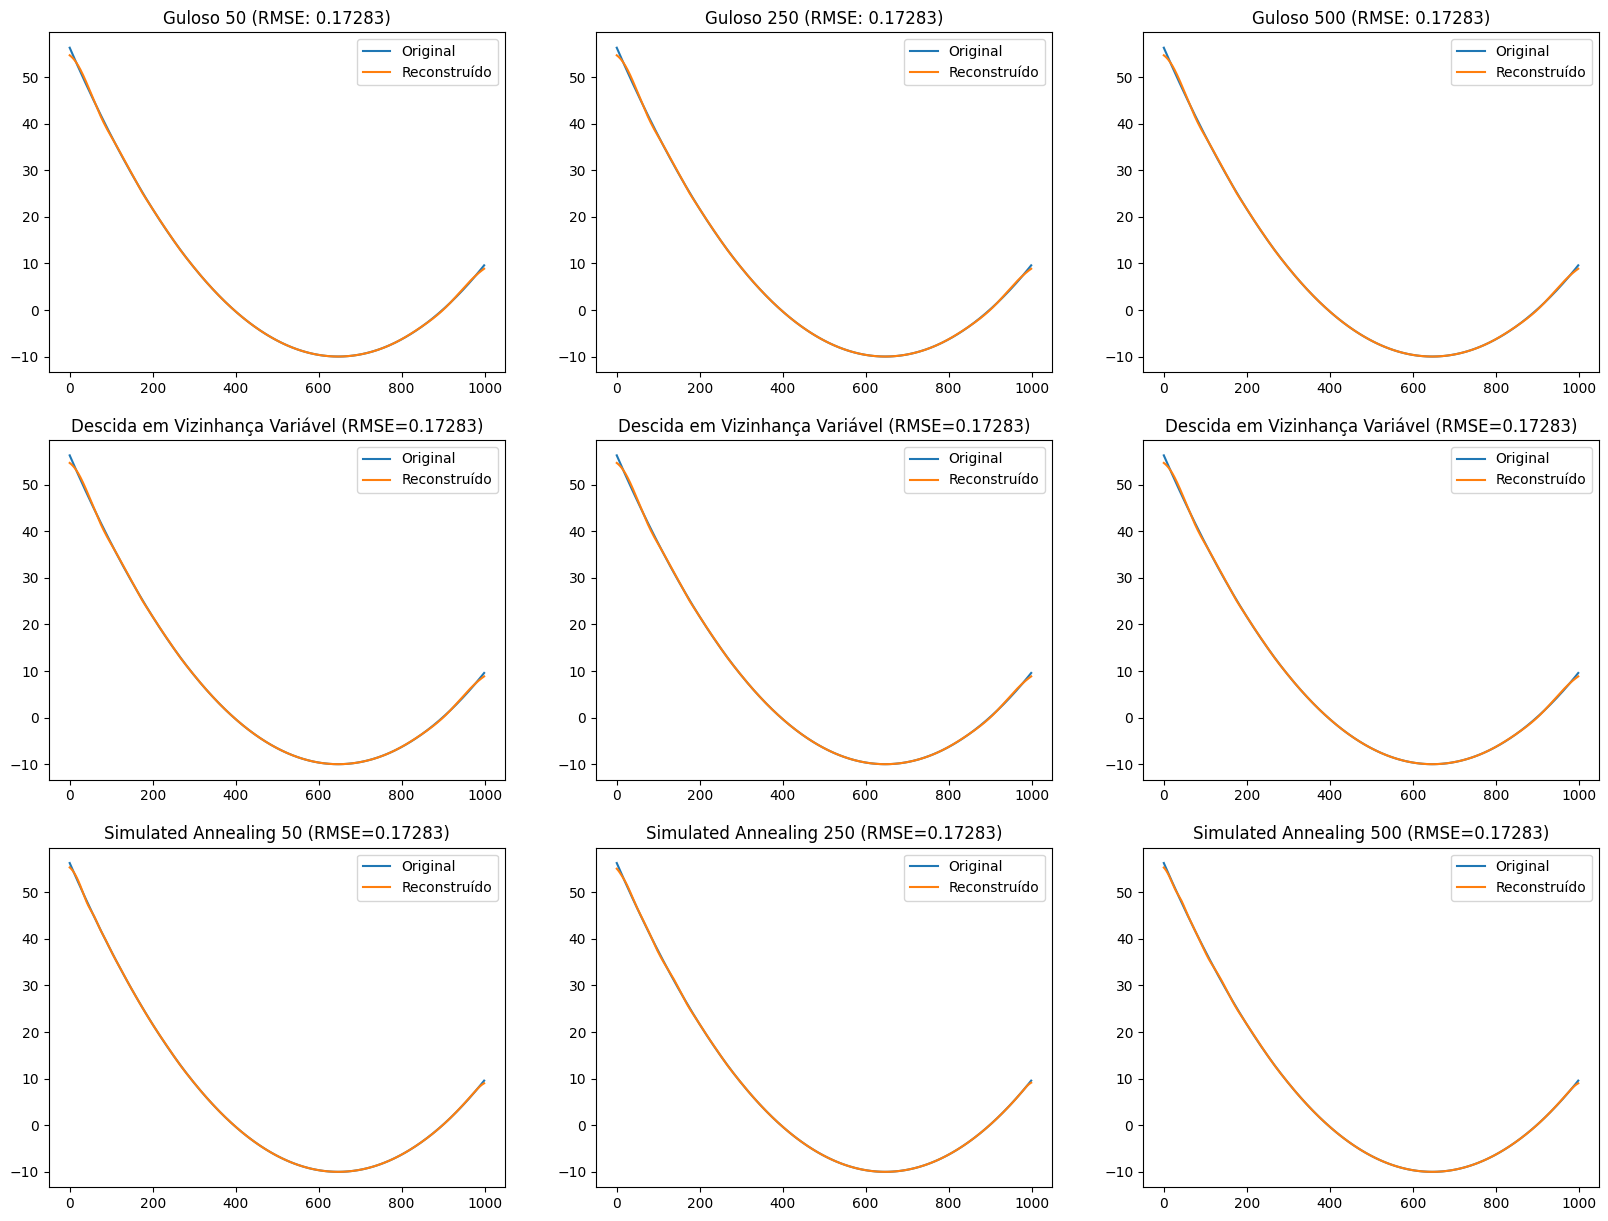


TEMPOS:
metodo guloso 50: 0.001499176025390625
metodo guloso 250: 0.001222372055053711
metodo guloso 500: 0.001178741455078125
DVV50: 0.0017960071563720703
DVV250: 0.001583099365234375
DVV500: 0.0021669864654541016
Simulated Annealing 50: 85.0070436000824
Simulated Annealing 250: 73.29932355880737
Simulated Annealing 500: 73.23035597801208


In [ ]:
a = np.linspace(-np.pi, 3*np.pi, 1000)
x = a**2 - 10*a + 15

wavelet = 'db7'

start = time.time()
c = pywt.wavedec(x, wavelet)
end = time.time()

base = end - start

# =====================


plt.figure(figsize=(20,15))
plt.axis('off')

# GULOSO 50
plt.subplot(331)
start = time.time()
g50 = algoritmo_guloso(c, 50)
y = pywt.waverec(g50, wavelet)
t50 = base + (time.time() - start)
exibir(x, y, f'Guloso 50 (RMSE: {np.sqrt(np.mean((x - y)**2)):.5f})')

# GULOSO 250
plt.subplot(332)
start = time.time()
g250 = algoritmo_guloso(c, 250)
y = pywt.waverec(g250, wavelet)
t250 = base + (time.time() - start)
exibir(x, y, f'Guloso 250 (RMSE: {np.sqrt(np.mean((x - y)**2)):.5f})')

# GULOSO 500
plt.subplot(333)
start = time.time()
g500 = algoritmo_guloso(c, 500)
y = pywt.waverec(g500, wavelet)
t500 = base + (time.time() - start)
exibir(x, y, f'Guloso 500 (RMSE: {np.sqrt(np.mean((x - y)**2)):.5f})')

# Descida em Vizinhança Variável 50
plt.subplot(334)
start = time.time()
hc, err = dvv(c, x, 50)
y = pywt.waverec(hc, wavelet)
dvv50 = base + (time.time() - start)
exibir(x, y, f'Descida em Vizinhança Variável (RMSE={err:.5f})')

# Descida em Vizinhança Variável 250
plt.subplot(335)
start = time.time()
hc, err = dvv(c, x, 250)
y = pywt.waverec(hc, wavelet)
dvv250 = base + (time.time() - start)
exibir(x, y, f'Descida em Vizinhança Variável (RMSE={err:.5f})')


# Descida em Vizinhança Variável 500
plt.subplot(336)
start = time.time()
hc, err = dvv(c, x, 500)
y = pywt.waverec(hc, wavelet)
dvv500 = base + (time.time() - start)
exibir(x, y, f'Descida em Vizinhança Variável (RMSE={err:.5f})')

# Simulated Annealing 50
plt.subplot(337)
start = time.time()
s_inicial = algoritmo_guloso(c, capacidade=50)
melhor, melhor_custo, _ = simulated_annealing(s_inicial, c)
y = pywt.waverec(melhor, wavelet)
sa50 = base + (time.time() - start)
exibir(x, y, f'Simulated Annealing 50 (RMSE={err:.5f})')

# Simulated Annealing 250
plt.subplot(338)
start = time.time()
s_inicial = algoritmo_guloso(c, capacidade=250)
melhor, melhor_custo, _ = simulated_annealing(s_inicial, c)
y = pywt.waverec(melhor, wavelet)
sa250 = base + (time.time() - start)
exibir(x, y, f'Simulated Annealing 250 (RMSE={err:.5f})')

# Simulated Annealing 500
plt.subplot(339)
start = time.time()
s_inicial = algoritmo_guloso(c, capacidade=500)
melhor, melhor_custo, _ = simulated_annealing(s_inicial, c)
y = pywt.waverec(melhor, wavelet)
sa500 = base + (time.time() - start)
exibir(x, y, f'Simulated Annealing 500 (RMSE={err:.5f})')

plt.show()

print("\nTEMPOS:")
print("metodo guloso 50:", t50)
print("metodo guloso 250:", t250)
print("metodo guloso 500:", t500)
print("DVV50:", dvv50)
print("DVV250:", dvv250)
print("DVV500:", dvv500)
print("Simulated Annealing 50:", sa50)
print("Simulated Annealing 250:", sa250)
print("Simulated Annealing 500:",sa500)




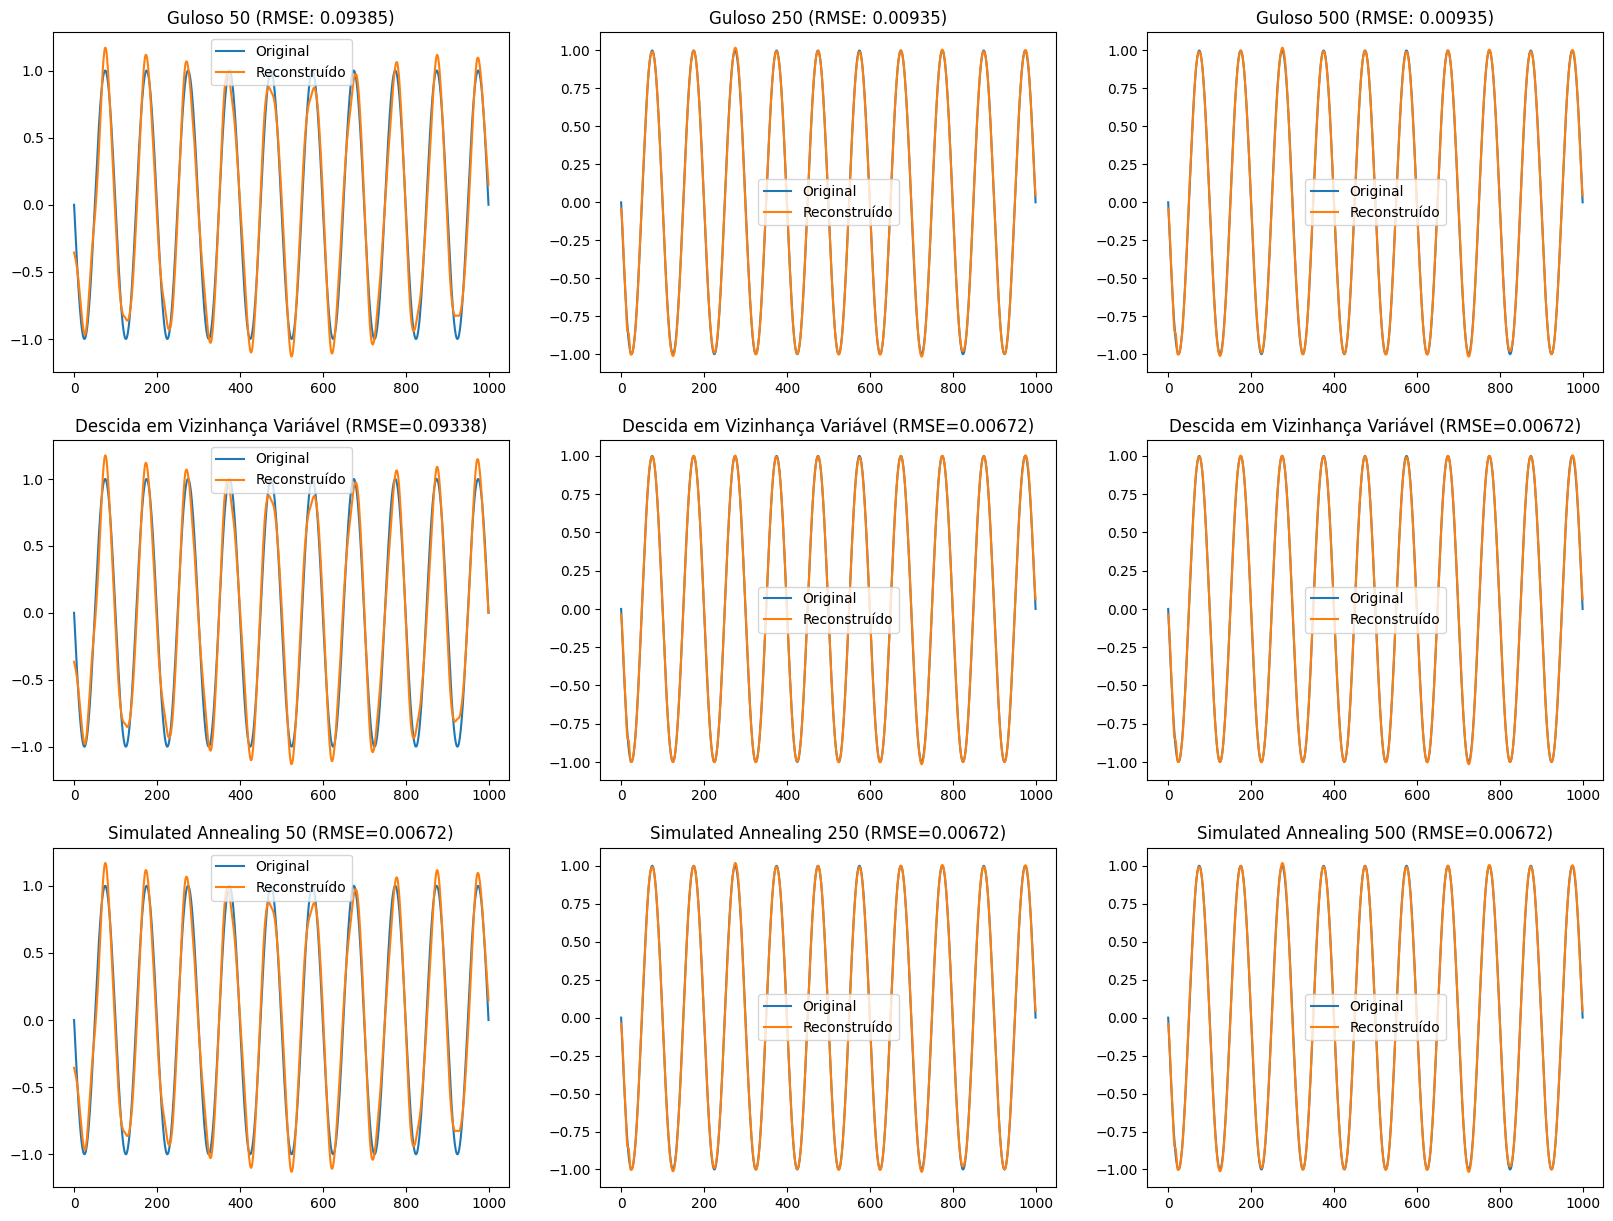


TEMPOS:
metodo guloso 50: 0.0013110637664794922
metodo guloso 250: 0.0009357929229736328
metodo guloso 500: 0.0009655952453613281
DVV50: 0.08760643005371094
DVV250: 0.3697965145111084
DVV500: 0.3669116497039795
Simulated Annealing 50: 70.44665718078613
Simulated Annealing 250: 74.4029712677002
Simulated Annealing 500: 73.35307359695435


In [ ]:
a = np.linspace(-np.pi, 3*np.pi, 1000)
x = np.sin(5*a)

wavelet = 'db7'

start = time.time()
c = pywt.wavedec(x, wavelet)
end = time.time()

base = end - start

# =====================


plt.figure(figsize=(20,15))
plt.axis('off')

# GULOSO 50
plt.subplot(331)
start = time.time()
g50 = algoritmo_guloso(c, 50)
y = pywt.waverec(g50, wavelet)
t50 = base + (time.time() - start)
exibir(x, y, f'Guloso 50 (RMSE: {np.sqrt(np.mean((x - y)**2)):.5f})')

# GULOSO 250
plt.subplot(332)
start = time.time()
g250 = algoritmo_guloso(c, 250)
y = pywt.waverec(g250, wavelet)
t250 = base + (time.time() - start)
exibir(x, y, f'Guloso 250 (RMSE: {np.sqrt(np.mean((x - y)**2)):.5f})')

# GULOSO 500
plt.subplot(333)
start = time.time()
g500 = algoritmo_guloso(c, 500)
y = pywt.waverec(g500, wavelet)
t500 = base + (time.time() - start)
exibir(x, y, f'Guloso 500 (RMSE: {np.sqrt(np.mean((x - y)**2)):.5f})')

# Descida em Vizinhança Variável 50
plt.subplot(334)
start = time.time()
hc, err = dvv(c, x, 50)
y = pywt.waverec(hc, wavelet)
dvv50 = base + (time.time() - start)
exibir(x, y, f'Descida em Vizinhança Variável (RMSE={err:.5f})')

# Descida em Vizinhança Variável 250
plt.subplot(335)
start = time.time()
hc, err = dvv(c, x, 250)
y = pywt.waverec(hc, wavelet)
dvv250 = base + (time.time() - start)
exibir(x, y, f'Descida em Vizinhança Variável (RMSE={err:.5f})')


# Descida em Vizinhança Variável 500
plt.subplot(336)
start = time.time()
hc, err = dvv(c, x, 500)
y = pywt.waverec(hc, wavelet)
dvv500 = base + (time.time() - start)
exibir(x, y, f'Descida em Vizinhança Variável (RMSE={err:.5f})')

# Simulated Annealing 50
plt.subplot(337)
start = time.time()
s_inicial = algoritmo_guloso(c, capacidade=50)
melhor, melhor_custo, _ = simulated_annealing(s_inicial, c)
y = pywt.waverec(melhor, wavelet)
sa50 = base + (time.time() - start)
exibir(x, y, f'Simulated Annealing 50 (RMSE={err:.5f})')

# Simulated Annealing 250
plt.subplot(338)
start = time.time()
s_inicial = algoritmo_guloso(c, capacidade=250)
melhor, melhor_custo, _ = simulated_annealing(s_inicial, c)
y = pywt.waverec(melhor, wavelet)
sa250 = base + (time.time() - start)
exibir(x, y, f'Simulated Annealing 250 (RMSE={err:.5f})')

# Simulated Annealing 500
plt.subplot(339)
start = time.time()
s_inicial = algoritmo_guloso(c, capacidade=500)
melhor, melhor_custo, _ = simulated_annealing(s_inicial, c)
y = pywt.waverec(melhor, wavelet)
sa500 = base + (time.time() - start)
exibir(x, y, f'Simulated Annealing 500 (RMSE={err:.5f})')

plt.show()

print("\nTEMPOS:")
print("metodo guloso 50:", t50)
print("metodo guloso 250:", t250)
print("metodo guloso 500:", t500)
print("DVV50:", dvv50)
print("DVV250:", dvv250)
print("DVV500:", dvv500)
print("Simulated Annealing 50:", sa50)
print("Simulated Annealing 250:", sa250)
print("Simulated Annealing 500:",sa500)

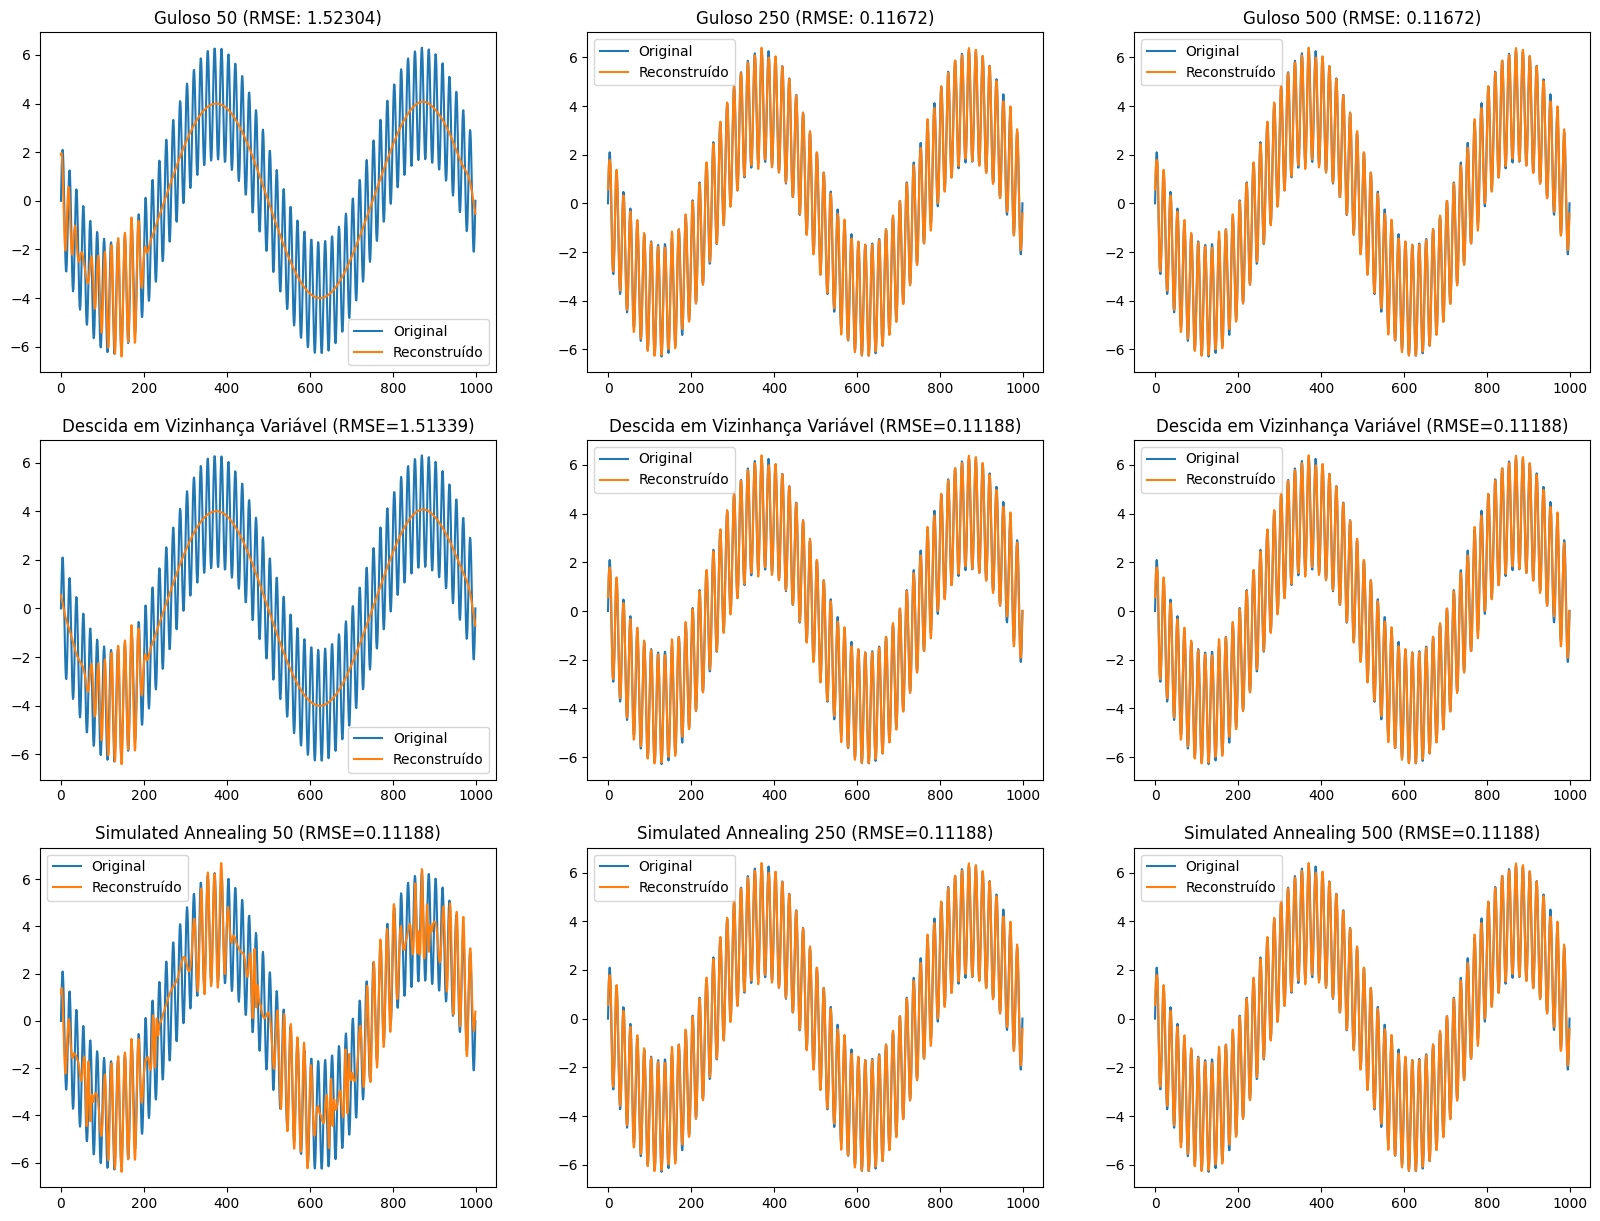


TEMPOS:
metodo guloso 50: 0.004082918167114258
metodo guloso 250: 0.003841876983642578
metodo guloso 500: 0.0032944679260253906
DVV50: 0.13159608840942383
DVV250: 0.5869722366333008
DVV500: 0.5998287200927734
Simulated Annealing 50: 71.83727717399597
Simulated Annealing 250: 73.54973936080933
Simulated Annealing 500: 70.83907842636108


In [ ]:
a = np.linspace(-np.pi, 3*np.pi, 1000)
x = 4*np.sin(a) + 2.3*np.sin(a*30)

wavelet = 'db7'

start = time.time()
c = pywt.wavedec(x, wavelet)
end = time.time()

base = end - start

# =====================


plt.figure(figsize=(20,15))
plt.axis('off')

# GULOSO 50
plt.subplot(331)
start = time.time()
g50 = algoritmo_guloso(c, 50)
y = pywt.waverec(g50, wavelet)
t50 = base + (time.time() - start)
exibir(x, y, f'Guloso 50 (RMSE: {np.sqrt(np.mean((x - y)**2)):.5f})')

# GULOSO 250
plt.subplot(332)
start = time.time()
g250 = algoritmo_guloso(c, 250)
y = pywt.waverec(g250, wavelet)
t250 = base + (time.time() - start)
exibir(x, y, f'Guloso 250 (RMSE: {np.sqrt(np.mean((x - y)**2)):.5f})')

# GULOSO 500
plt.subplot(333)
start = time.time()
g500 = algoritmo_guloso(c, 500)
y = pywt.waverec(g500, wavelet)
t500 = base + (time.time() - start)
exibir(x, y, f'Guloso 500 (RMSE: {np.sqrt(np.mean((x - y)**2)):.5f})')

# Descida em Vizinhança Variável 50
plt.subplot(334)
start = time.time()
hc, err = dvv(c, x, 50)
y = pywt.waverec(hc, wavelet)
dvv50 = base + (time.time() - start)
exibir(x, y, f'Descida em Vizinhança Variável (RMSE={err:.5f})')

# Descida em Vizinhança Variável 250
plt.subplot(335)
start = time.time()
hc, err = dvv(c, x, 250)
y = pywt.waverec(hc, wavelet)
dvv250 = base + (time.time() - start)
exibir(x, y, f'Descida em Vizinhança Variável (RMSE={err:.5f})')


# Descida em Vizinhança Variável 500
plt.subplot(336)
start = time.time()
hc, err = dvv(c, x, 500)
y = pywt.waverec(hc, wavelet)
dvv500 = base + (time.time() - start)
exibir(x, y, f'Descida em Vizinhança Variável (RMSE={err:.5f})')

# Simulated Annealing 50
plt.subplot(337)
start = time.time()
s_inicial = algoritmo_guloso(c, capacidade=50)
melhor, melhor_custo, _ = simulated_annealing(s_inicial, c)
y = pywt.waverec(melhor, wavelet)
sa50 = base + (time.time() - start)
exibir(x, y, f'Simulated Annealing 50 (RMSE={err:.5f})')

# Simulated Annealing 250
plt.subplot(338)
start = time.time()
s_inicial = algoritmo_guloso(c, capacidade=250)
melhor, melhor_custo, _ = simulated_annealing(s_inicial, c)
y = pywt.waverec(melhor, wavelet)
sa250 = base + (time.time() - start)
exibir(x, y, f'Simulated Annealing 250 (RMSE={err:.5f})')

# Simulated Annealing 500
plt.subplot(339)
start = time.time()
s_inicial = algoritmo_guloso(c, capacidade=500)
melhor, melhor_custo, _ = simulated_annealing(s_inicial, c)
y = pywt.waverec(melhor, wavelet)
sa500 = base + (time.time() - start)
exibir(x, y, f'Simulated Annealing 500 (RMSE={err:.5f})')

plt.show()

print("\nTEMPOS:")
print("metodo guloso 50:", t50)
print("metodo guloso 250:", t250)
print("metodo guloso 500:", t500)
print("DVV50:", dvv50)
print("DVV250:", dvv250)
print("DVV500:", dvv500)
print("Simulated Annealing 50:", sa50)
print("Simulated Annealing 250:", sa250)
print("Simulated Annealing 500:",sa500)

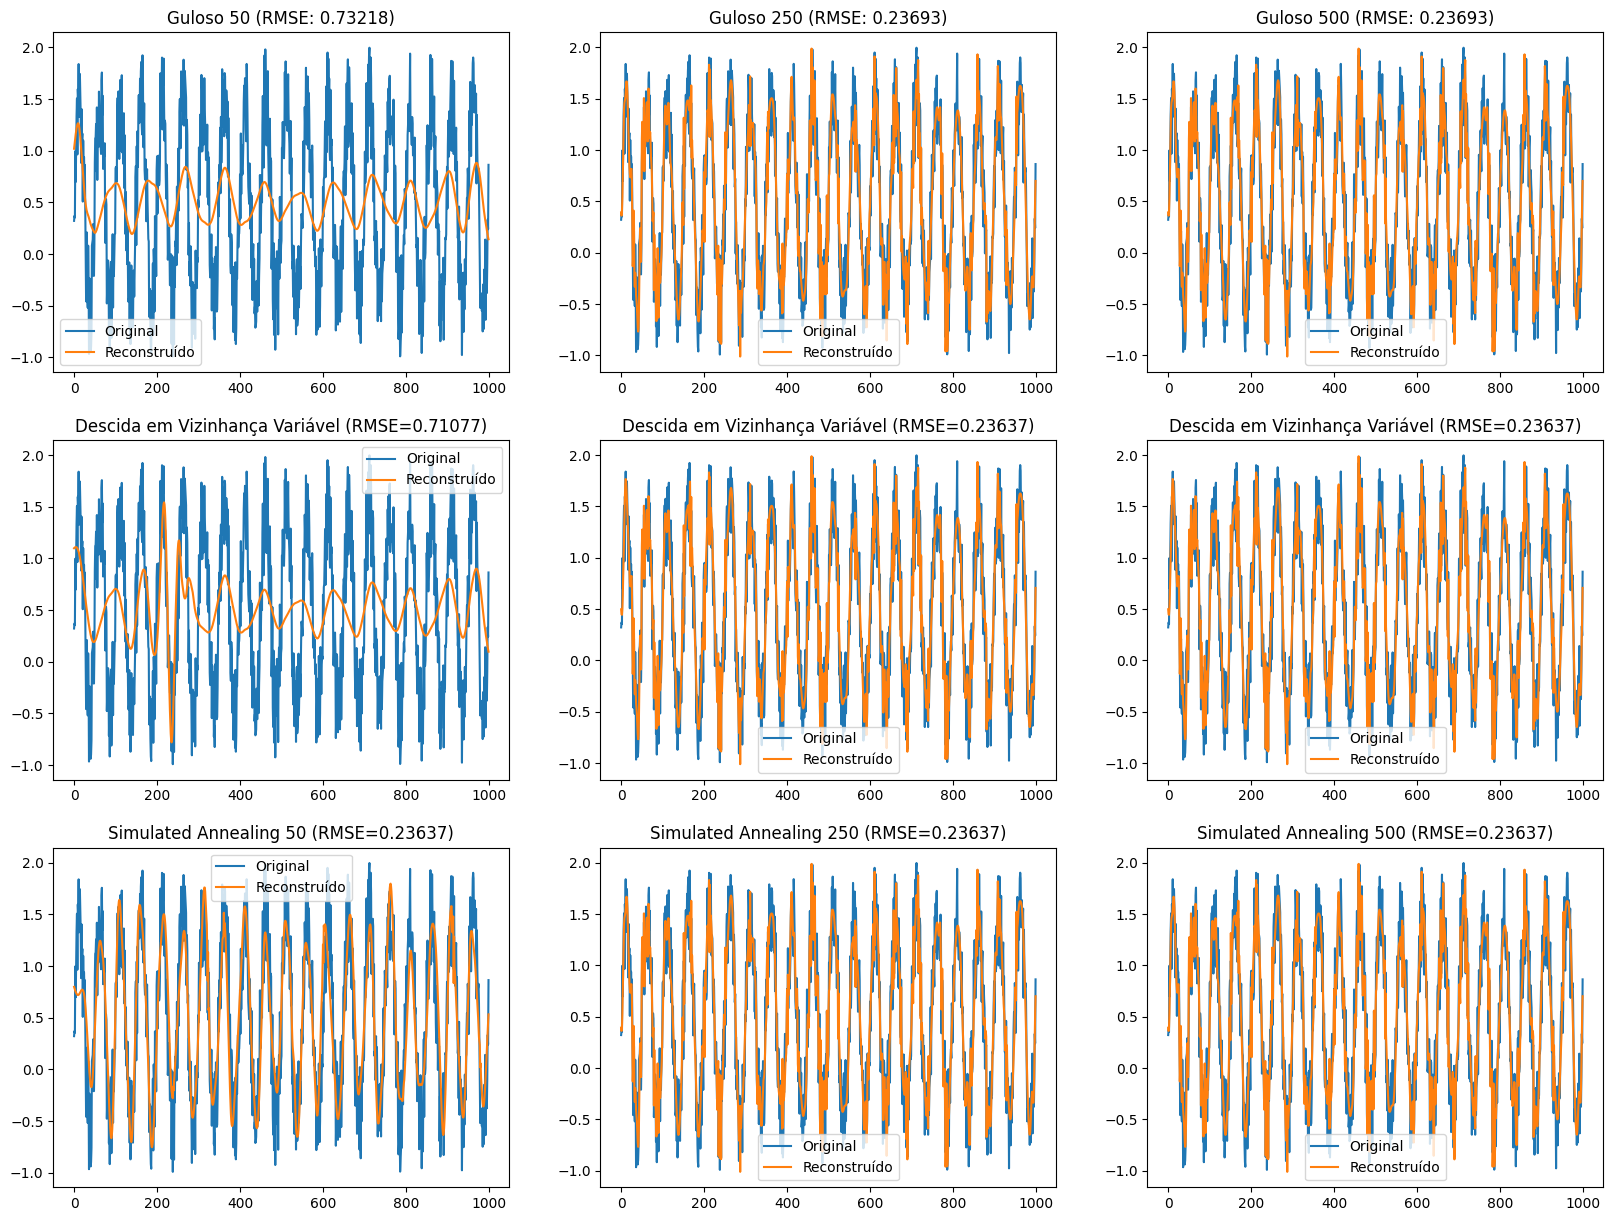


TEMPOS:
metodo guloso 50: 0.0019259452819824219
metodo guloso 250: 0.0013718605041503906
metodo guloso 500: 0.0013663768768310547
DVV50: 0.12357234954833984
DVV250: 4.488544225692749
DVV500: 3.393723726272583
Simulated Annealing 50: 71.11675977706909
Simulated Annealing 250: 71.75163793563843
Simulated Annealing 500: 72.00759935379028


In [ ]:
a = np.linspace(-np.pi, 3*np.pi, 1000)
x = np.sin(10*a) + np.random.rand(len(a))

wavelet = 'db7'

start = time.time()
c = pywt.wavedec(x, wavelet)
end = time.time()

base = end - start

# =====================


plt.figure(figsize=(20,15))
plt.axis('off')

# GULOSO 50
plt.subplot(331)
start = time.time()
g50 = algoritmo_guloso(c, 50)
y = pywt.waverec(g50, wavelet)
t50 = base + (time.time() - start)
exibir(x, y, f'Guloso 50 (RMSE: {np.sqrt(np.mean((x - y)**2)):.5f})')

# GULOSO 250
plt.subplot(332)
start = time.time()
g250 = algoritmo_guloso(c, 250)
y = pywt.waverec(g250, wavelet)
t250 = base + (time.time() - start)
exibir(x, y, f'Guloso 250 (RMSE: {np.sqrt(np.mean((x - y)**2)):.5f})')

# GULOSO 500
plt.subplot(333)
start = time.time()
g500 = algoritmo_guloso(c, 500)
y = pywt.waverec(g500, wavelet)
t500 = base + (time.time() - start)
exibir(x, y, f'Guloso 500 (RMSE: {np.sqrt(np.mean((x - y)**2)):.5f})')

# Descida em Vizinhança Variável 50
plt.subplot(334)
start = time.time()
hc, err = dvv(c, x, 50)
y = pywt.waverec(hc, wavelet)
dvv50 = base + (time.time() - start)
exibir(x, y, f'Descida em Vizinhança Variável (RMSE={err:.5f})')

# Descida em Vizinhança Variável 250
plt.subplot(335)
start = time.time()
hc, err = dvv(c, x, 250)
y = pywt.waverec(hc, wavelet)
dvv250 = base + (time.time() - start)
exibir(x, y, f'Descida em Vizinhança Variável (RMSE={err:.5f})')


# Descida em Vizinhança Variável 500
plt.subplot(336)
start = time.time()
hc, err = dvv(c, x, 500)
y = pywt.waverec(hc, wavelet)
dvv500 = base + (time.time() - start)
exibir(x, y, f'Descida em Vizinhança Variável (RMSE={err:.5f})')

# Simulated Annealing 50
plt.subplot(337)
start = time.time()
s_inicial = algoritmo_guloso(c, capacidade=50)
melhor, melhor_custo, _ = simulated_annealing(s_inicial, c)
y = pywt.waverec(melhor, wavelet)
sa50 = base + (time.time() - start)
exibir(x, y, f'Simulated Annealing 50 (RMSE={err:.5f})')

# Simulated Annealing 250
plt.subplot(338)
start = time.time()
s_inicial = algoritmo_guloso(c, capacidade=250)
melhor, melhor_custo, _ = simulated_annealing(s_inicial, c)
y = pywt.waverec(melhor, wavelet)
sa250 = base + (time.time() - start)
exibir(x, y, f'Simulated Annealing 250 (RMSE={err:.5f})')

# Simulated Annealing 500
plt.subplot(339)
start = time.time()
s_inicial = algoritmo_guloso(c, capacidade=500)
melhor, melhor_custo, _ = simulated_annealing(s_inicial, c)
y = pywt.waverec(melhor, wavelet)
sa500 = base + (time.time() - start)
exibir(x, y, f'Simulated Annealing 500 (RMSE={err:.5f})')

plt.show()

print("\nTEMPOS:")
print("metodo guloso 50:", t50)
print("metodo guloso 250:", t250)
print("metodo guloso 500:", t500)
print("DVV50:", dvv50)
print("DVV250:", dvv250)
print("DVV500:", dvv500)
print("Simulated Annealing 50:", sa50)
print("Simulated Annealing 250:", sa250)
print("Simulated Annealing 500:",sa500)


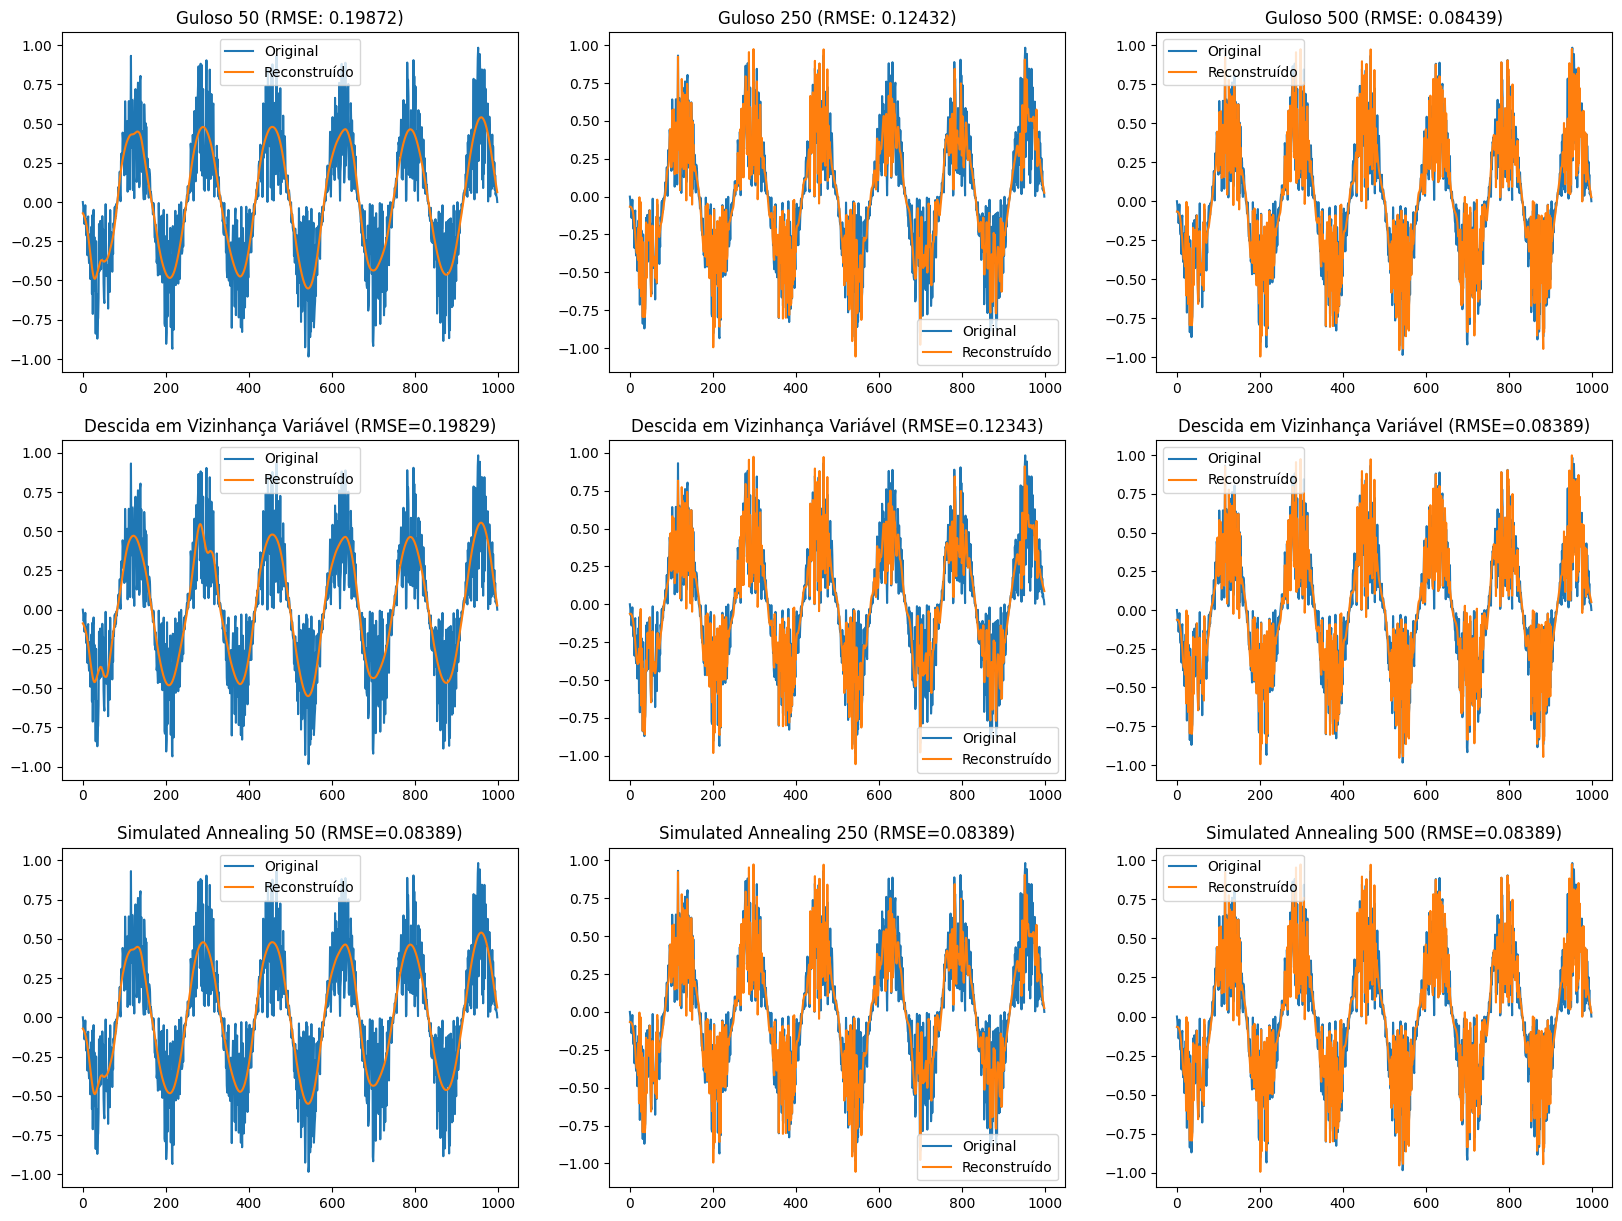


TEMPOS:
metodo guloso 50: 0.0010209083557128906
metodo guloso 250: 0.0013091564178466797
metodo guloso 500: 0.0016672611236572266
DVV50: 0.0557560920715332
DVV250: 6.497998237609863
DVV500: 17.22697877883911
Simulated Annealing 50: 70.9208242893219
Simulated Annealing 250: 72.32029390335083
Simulated Annealing 500: 71.58816123008728


In [ ]:
a = np.linspace(-np.pi, 3*np.pi, 1000)
x = np.sin(3*a)*np.random.rand(len(a))

wavelet = 'db7'

start = time.time()
c = pywt.wavedec(x, wavelet)
end = time.time()

base = end - start

# =====================


plt.figure(figsize=(20,15))
plt.axis('off')

# GULOSO 50
plt.subplot(331)
start = time.time()
g50 = algoritmo_guloso(c, 50)
y = pywt.waverec(g50, wavelet)
t50 = base + (time.time() - start)
exibir(x, y, f'Guloso 50 (RMSE: {np.sqrt(np.mean((x - y)**2)):.5f})')

# GULOSO 250
plt.subplot(332)
start = time.time()
g250 = algoritmo_guloso(c, 250)
y = pywt.waverec(g250, wavelet)
t250 = base + (time.time() - start)
exibir(x, y, f'Guloso 250 (RMSE: {np.sqrt(np.mean((x - y)**2)):.5f})')

# GULOSO 500
plt.subplot(333)
start = time.time()
g500 = algoritmo_guloso(c, 500)
y = pywt.waverec(g500, wavelet)
t500 = base + (time.time() - start)
exibir(x, y, f'Guloso 500 (RMSE: {np.sqrt(np.mean((x - y)**2)):.5f})')

# Descida em Vizinhança Variável 50
plt.subplot(334)
start = time.time()
hc, err = dvv(c, x, 50)
y = pywt.waverec(hc, wavelet)
dvv50 = base + (time.time() - start)
exibir(x, y, f'Descida em Vizinhança Variável (RMSE={err:.5f})')

# Descida em Vizinhança Variável 250
plt.subplot(335)
start = time.time()
hc, err = dvv(c, x, 250)
y = pywt.waverec(hc, wavelet)
dvv250 = base + (time.time() - start)
exibir(x, y, f'Descida em Vizinhança Variável (RMSE={err:.5f})')


# Descida em Vizinhança Variável 500
plt.subplot(336)
start = time.time()
hc, err = dvv(c, x, 500)
y = pywt.waverec(hc, wavelet)
dvv500 = base + (time.time() - start)
exibir(x, y, f'Descida em Vizinhança Variável (RMSE={err:.5f})')

# Simulated Annealing 50
plt.subplot(337)
start = time.time()
s_inicial = algoritmo_guloso(c, capacidade=50)
melhor, melhor_custo, _ = simulated_annealing(s_inicial, c)
y = pywt.waverec(melhor, wavelet)
sa50 = base + (time.time() - start)
exibir(x, y, f'Simulated Annealing 50 (RMSE={err:.5f})')

# Simulated Annealing 250
plt.subplot(338)
start = time.time()
s_inicial = algoritmo_guloso(c, capacidade=250)
melhor, melhor_custo, _ = simulated_annealing(s_inicial, c)
y = pywt.waverec(melhor, wavelet)
sa250 = base + (time.time() - start)
exibir(x, y, f'Simulated Annealing 250 (RMSE={err:.5f})')

# Simulated Annealing 500
plt.subplot(339)
start = time.time()
s_inicial = algoritmo_guloso(c, capacidade=500)
melhor, melhor_custo, _ = simulated_annealing(s_inicial, c)
y = pywt.waverec(melhor, wavelet)
sa500 = base + (time.time() - start)
exibir(x, y, f'Simulated Annealing 500 (RMSE={err:.5f})')

plt.show()

print("\nTEMPOS:")
print("metodo guloso 50:", t50)
print("metodo guloso 250:", t250)
print("metodo guloso 500:", t500)
print("DVV50:", dvv50)
print("DVV250:", dvv250)
print("DVV500:", dvv500)
print("Simulated Annealing 50:", sa50)
print("Simulated Annealing 250:", sa250)
print("Simulated Annealing 500:",sa500)

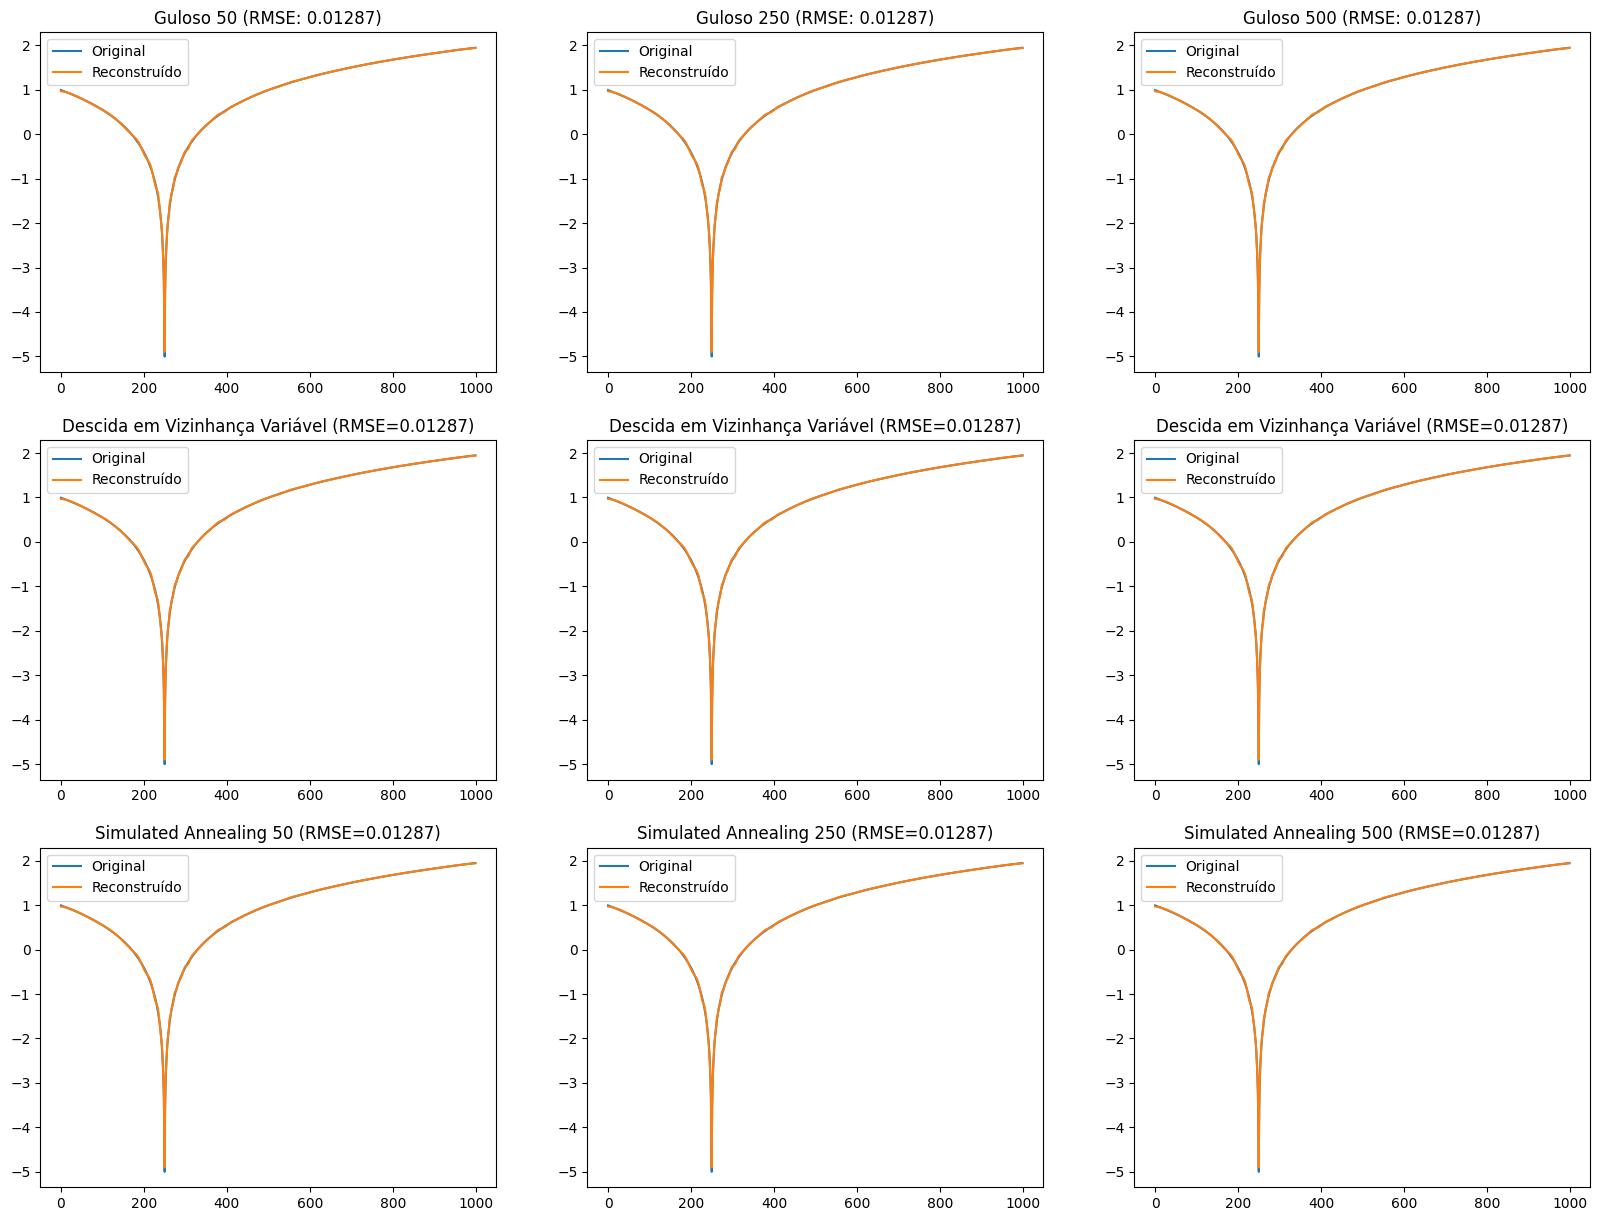


TEMPOS:
metodo guloso 50: 0.0014190673828125
metodo guloso 250: 0.0016744136810302734
metodo guloso 500: 0.0010912418365478516
DVV50: 0.23011326789855957
DVV250: 0.23084616661071777
DVV500: 0.24354290962219238
Simulated Annealing 50: 72.29808402061462
Simulated Annealing 250: 70.78438210487366
Simulated Annealing 500: 74.27858662605286


In [ ]:
a = np.linspace(-np.pi, 3*np.pi, 1000)
x = np.log10(a**2)

wavelet = 'db7'

start = time.time()
c = pywt.wavedec(x, wavelet)
end = time.time()

base = end - start

# =====================


plt.figure(figsize=(20,15))
plt.axis('off')

# GULOSO 50
plt.subplot(331)
start = time.time()
g50 = algoritmo_guloso(c, 50)
y = pywt.waverec(g50, wavelet)
t50 = base + (time.time() - start)
exibir(x, y, f'Guloso 50 (RMSE: {np.sqrt(np.mean((x - y)**2)):.5f})')

# GULOSO 250
plt.subplot(332)
start = time.time()
g250 = algoritmo_guloso(c, 250)
y = pywt.waverec(g250, wavelet)
t250 = base + (time.time() - start)
exibir(x, y, f'Guloso 250 (RMSE: {np.sqrt(np.mean((x - y)**2)):.5f})')

# GULOSO 500
plt.subplot(333)
start = time.time()
g500 = algoritmo_guloso(c, 500)
y = pywt.waverec(g500, wavelet)
t500 = base + (time.time() - start)
exibir(x, y, f'Guloso 500 (RMSE: {np.sqrt(np.mean((x - y)**2)):.5f})')

# Descida em Vizinhança Variável 50
plt.subplot(334)
start = time.time()
hc, err = dvv(c, x, 50)
y = pywt.waverec(hc, wavelet)
dvv50 = base + (time.time() - start)
exibir(x, y, f'Descida em Vizinhança Variável (RMSE={err:.5f})')

# Descida em Vizinhança Variável 250
plt.subplot(335)
start = time.time()
hc, err = dvv(c, x, 250)
y = pywt.waverec(hc, wavelet)
dvv250 = base + (time.time() - start)
exibir(x, y, f'Descida em Vizinhança Variável (RMSE={err:.5f})')


# Descida em Vizinhança Variável 500
plt.subplot(336)
start = time.time()
hc, err = dvv(c, x, 500)
y = pywt.waverec(hc, wavelet)
dvv500 = base + (time.time() - start)
exibir(x, y, f'Descida em Vizinhança Variável (RMSE={err:.5f})')

# Simulated Annealing 50
plt.subplot(337)
start = time.time()
s_inicial = algoritmo_guloso(c, capacidade=50)
melhor, melhor_custo, _ = simulated_annealing(s_inicial, c)
y = pywt.waverec(melhor, wavelet)
sa50 = base + (time.time() - start)
exibir(x, y, f'Simulated Annealing 50 (RMSE={err:.5f})')

# Simulated Annealing 250
plt.subplot(338)
start = time.time()
s_inicial = algoritmo_guloso(c, capacidade=250)
melhor, melhor_custo, _ = simulated_annealing(s_inicial, c)
y = pywt.waverec(melhor, wavelet)
sa250 = base + (time.time() - start)
exibir(x, y, f'Simulated Annealing 250 (RMSE={err:.5f})')

# Simulated Annealing 500
plt.subplot(339)
start = time.time()
s_inicial = algoritmo_guloso(c, capacidade=500)
melhor, melhor_custo, _ = simulated_annealing(s_inicial, c)
y = pywt.waverec(melhor, wavelet)
sa500 = base + (time.time() - start)
exibir(x, y, f'Simulated Annealing 500 (RMSE={err:.5f})')

plt.show()

print("\nTEMPOS:")
print("metodo guloso 50:", t50)
print("metodo guloso 250:", t250)
print("metodo guloso 500:", t500)
print("DVV50:", dvv50)
print("DVV250:", dvv250)
print("DVV500:", dvv500)
print("Simulated Annealing 50:", sa50)
print("Simulated Annealing 250:", sa250)
print("Simulated Annealing 500:",sa500)


## Conclusões parciais

### Método Guloso:
- Para sinais simples (funções afim, quadrática, log(a)), mesmo com poucos coeficientes mantidos, a reconstrução do sinal apresentou perda mínima de informação;
- Para senoides com frequencias um pouco elevadas, o sinal final não foi bem reconstruído, mesmo com o aumento de coeficientes mantidos;
- Em sinais ruidosos ou com variações bruscas, estes pequenos detalhes não foram mantidos fielmente;
- A seleção por método guloso parece impactar diretamente a qualidade do sinal ao longo do tempo: sinais mais complexos perderam muita informação em porções médias e finais quando poucos coeficentes foram armazenados.

### Heurísitca de Refinamento Descida em Vizinhança Variável:
- Para as mesmas funções afim, quadrática e log com perda mínima e constante para os diferentes tamanhos de mochila no algoritmo guloso, a situação se manteve com a Descida em Vizinhança Variável. Não houve variação do RMSE, somente o tempo de execução aumentou.
- Para as demais funções (maioria), ouve diminuição do RMSE. Em muitos casos, para um valor constante. Não é possível identificar com precisão se esse valor seria a solução ótima para o tamanho da mochila utilizado ou não.
- O tempo de execução aumentou para a DVV em todos os casos. Isso era algo provável, pois seu código é uma etapa a mais para o método guloso.

### Simulated Annealing:
- Considerando os casos de testes analisados para os outros dois métodos, em apenas um dos casos, com capacidade=250, obteve-se uma melhoria em relação à já obtida no refinamento por Descida em Vizinhança Variável.
- O tempo obtido na execução do Simulated Annealing foi o maior entre os três métodos implementados para todos os casos de teste. Ele superou os 70 segundos em todas as implementações realizadas.
- Não é possível saber se os resultados obtidos, com ou sem melhoria identificada, são as solução ótimas para os problemas.  
